# Rossmann Store Sales: Promotion Impact Analysis

Because this is observational data, the analysis identifies associations between promotions and sales rather than proving that promotions directly caused changes in sales.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## 1. Data Loading and Preparation

In [7]:
df = pd.read_csv("../data/raw/train.csv")
df["Date"] = pd.to_datetime(df["Date"])
df.head()

C:\Users\prade\AppData\Local\Temp\ipykernel_9388\833762835.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/train.csv")


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [8]:
# Check dataset shape and missing values
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (1017209, 9)

Missing values:
Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64


## 2. Promotion Overview

Before comparing sales performance, this section examines how frequently promotions occur in the dataset.

The `Promo` variable indicates whether a promotion was active for a store on a given day:

* 0 = No promotion
* 1 = Promotion active

In [9]:
promo_counts = df["Promo"].value_counts().sort_index()

promo_summary = pd.DataFrame({
    "Count": promo_counts,
    "Percentage": (promo_counts / len(df) * 100).round(2)
})

promo_summary.index = ["No Promotion", "Promotion"]

promo_summary

,Count,Percentage
No Promotion,629129,61.85
Promotion,388080,38.15


- No promotion: 629,129 rows, 61.85%
- Promotion active: 388,080 rows, 38.15%

## 3. Sales on Promotion vs Non-Promotion Days

This section compares sales between observations with and without an active promotion.

The comparison provides an initial view of the relationship between promotions and sales. At this stage, differences should be interpreted as associations because other factors may also influence sales.

In [10]:
promo_sales_summary = df.groupby("Promo")["Sales"].agg(
    ["count", "mean", "median", "std"]
)

promo_sales_summary.index = ["No Promotion", "Promotion"]

promo_sales_summary

,count,mean,median,std
No Promotion,629129,4406.050805,4622.0,3442.450020
Promotion,388080,7991.152046,7553.0,3419.025495


Insight

|              | Mean Sales | Median Sales |
| ------------ | ---------: | -----------: |
| No Promotion |   4,406    |        4,622 |
| Promotion    |   7,991    |        7,553 |





In [11]:
no_promo_mean = promo_sales_summary.loc["No Promotion", "mean"]
promo_mean = promo_sales_summary.loc["Promotion", "mean"]

sales_difference = promo_mean - no_promo_mean
percentage_difference = (
    (promo_mean - no_promo_mean) / no_promo_mean
) * 100

print(f"Average sales without promotion: {no_promo_mean:,.2f}")
print(f"Average sales with promotion: {promo_mean:,.2f}")

print(f"\nDifference: {sales_difference:,.2f}")
print(f"Percentage difference: {percentage_difference:.2f}%")

Average sales without promotion: 4,406.05
Average sales with promotion: 7,991.15

Difference: 3,585.10
Percentage difference: 81.37%


Promotion days have -
- 3,585 higher average sales over no promotion days
- 81.4% higher mean sales over no promotion days


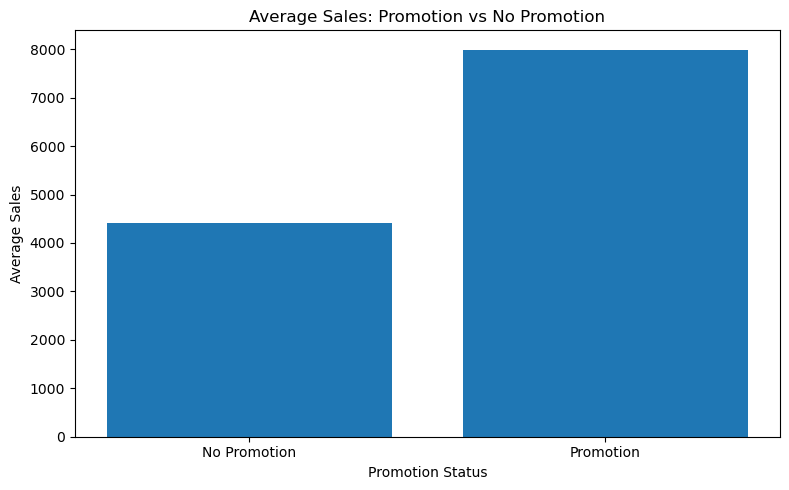

In [12]:
average_sales = df.groupby("Promo")["Sales"].mean()

plt.figure(figsize=(8, 5))
plt.bar(
    ["No Promotion", "Promotion"],
    average_sales.values
)

plt.title("Average Sales: Promotion vs No Promotion")
plt.xlabel("Promotion Status")
plt.ylabel("Average Sales")

plt.tight_layout()
plt.show()

Average Sales are usually much higher on **Promotion days** compared to **No Promotion** days

## 4. Promotion Comparison Within Stores

Stores differ substantially in their typical sales levels. Comparing all promotional observations against all non-promotional observations can therefore mix promotion patterns with differences between stores.

This section compares average sales with and without promotions for each store.

In [ ]:
# for each store how much difference did promotions make
store_promo_sales = (
    df.groupby(["Store", "Promo"])["Sales"]
    .mean()
    .unstack()
)

store_promo_sales.columns = ["No Promotion", "Promotion"]
store_promo_sales["Difference"] = (
    store_promo_sales["Promotion"]
    - store_promo_sales["No Promotion"]
)

store_promo_sales.head(10)

,No Promotion,Promotion,Difference
Store,,,
1,3198.994845,5152.886111,1953.891266
2,2855.058419,6172.816667,3317.758247
3,3967.596220,8608.666667,4641.070447
4,6568.939863,10370.511111,3801.571249
5,2582.271478,5944.266667,3361.995189
6,3367.108247,6494.725000,3127.616753
7,5506.898625,10347.741667,4840.843041
8,3147.664948,6974.766667,3827.101718
9,4227.345361,7365.961111,3138.615750


In [16]:
# Remove stores that do not have observations in both groups
valid_stores = store_promo_sales.dropna(
    subset=["No Promotion", "Promotion"])

higher_with_promo = (valid_stores["Difference"] > 0).sum()
lower_with_promo = (valid_stores["Difference"] < 0).sum()
no_difference = (valid_stores["Difference"] == 0).sum()

print("Stores with both promotion and non-promotion observations:",
len(valid_stores))

print("\nStores with higher average sales during promotions:",
      higher_with_promo)

print("Stores with lower average sales during promotions:",
      lower_with_promo)

print("Stores with no difference:",
      no_difference)

print(f"\nPercentage with higher sales during promotions: "
    f"{higher_with_promo / len(valid_stores) * 100:.2f}%")

Stores with both promotion and non-promotion observations: 1115

Stores with higher average sales during promotions: 1114
Stores with lower average sales during promotions: 1
Stores with no difference: 0

Percentage with higher sales during promotions: 99.91%


Out of the 1115 total stores - 

- 1114 out of 1115 stores had higher average sales when there is a promotion
- 99.91% of stores experienced higher average sales with promotions

- No promotion mean sales: 4,406.05
- Promotion mean sales: 7,991.15
- Difference: 3,585.10
- Unadjusted increase: 81.37%

### Store-Level Insight

The positive association between promotions and sales was highly consistent across stores.

Among the 1,115 stores with both promotional and non-promotional observations, 1,114 stores (99.91%) had higher average sales during promotional periods.

This suggests that the overall difference in average sales is widespread across the store network rather than being driven by a small number of unusually high-performing stores.

However, this remains an observational comparison. Calendar effects, holidays, seasonality, and other unobserved factors may still influence both promotion timing and sales.

## 5. Promotion Comparison After Controlling for Calendar Factors

Sales can vary substantially depending on the day of the week and whether a school or state holiday occurs.

To reduce the influence of these calendar differences, promotions are compared within groups that share the same:

- Day of week
- School holiday status
- State holiday status

This does not establish causality, but it provides a more controlled descriptive comparison than the overall promotion versus non-promotion averages.

In [17]:
calendar_promo_sales = (
    df.groupby(
        ["DayOfWeek", "SchoolHoliday", "StateHoliday", "Promo"]
    )["Sales"]
    .mean()
    .unstack()
)

calendar_promo_sales.columns = ["No Promotion", "Promotion"]

calendar_promo_sales["Difference"] = (
    calendar_promo_sales["Promotion"]
    - calendar_promo_sales["No Promotion"]
)

calendar_promo_sales.head(10)

No Promotion    Promotion   Difference
DayOfWeek SchoolHoliday StateHoliday                                        
1         0             0              5691.848773  9646.586263  3954.737490
                        0              5901.639531  9748.521433  3846.881902
                        a               257.366972    81.766990  -175.599982
                        b               388.210317          NaN          NaN
          1             0              5959.056744  9670.410920  3711.354176
                        0              7577.492482  9806.035326  2228.542845
                        a                 0.000000          NaN          NaN
                        b               212.465567          NaN          NaN
2         0             0              5374.646552  8023.228360  2648.581809
                        0              5585.665529  8302.329130  2716.663602

In [19]:
# Keep only calendar groups with both promotion and non-promotion observations
valid_calendar_groups = calendar_promo_sales.dropna(
    subset=["No Promotion", "Promotion"])
higher_calendar_groups = (
    valid_calendar_groups["Difference"] > 0).sum()
lower_calendar_groups = (
    valid_calendar_groups["Difference"] < 0).sum()
    
print(
    "Calendar groups with both promotion and non-promotion observations:",
    len(valid_calendar_groups))
print(
    "\nGroups with higher sales during promotions:",
    higher_calendar_groups)
print(
    "Groups with lower sales during promotions:",
    lower_calendar_groups)
print(
    f"\nPercentage with higher sales during promotions: "
    f"{higher_calendar_groups / len(valid_calendar_groups) * 100:.2f}%")

Calendar groups with both promotion and non-promotion observations: 25

Groups with higher sales during promotions: 24
Groups with lower sales during promotions: 1

Percentage with higher sales during promotions: 96.00%


## 6. Statistical Analysis of the Promotion Association

The previous comparisons showed that sales were generally higher during promotional periods, both across the full dataset and within individual stores.

This section uses a regression model to examine whether the association between promotions and sales remains after accounting for:

- Store-level differences
- Day of week
- School holidays
- State holidays

The results should still be interpreted as adjusted associations rather than causal effects because unobserved factors may influence both promotion timing and sales.

In [20]:
import statsmodels.formula.api as smf

In [21]:
# Focus on observations where stores were open
df_open = df[df["Open"] == 1].copy()

print("Original observations:", len(df))
print("Open-store observations:", len(df_open))
print(
    f"Percentage retained: {len(df_open) / len(df) * 100:.2f}%"
)

Original observations: 1017209
Open-store observations: 844392
Percentage retained: 83.01%


In [22]:
model = smf.ols(
    formula="""
        Sales ~ Promo
        + C(Store)
        + C(DayOfWeek)
        + SchoolHoliday
        + C(StateHoliday)
    """,
    data=df_open
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.764
Model:                            OLS   Adj. R-squared:                  0.764
Method:                 Least Squares   F-statistic:                     2428.
Date:                Sun, 30 Aug 2026   Prob (F-statistic):               0.00
Time:                        22:07:32   Log-Likelihood:            -7.3774e+06
No. Observations:              844392   AIC:                         1.476e+07
Df Residuals:                  843265   BIC:                         1.477e+07
Df Model:                        1126                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept             4404.8679 

In [23]:
promo_result = pd.DataFrame({
    "Coefficient": [model.params["Promo"]],
    "Std Error": [model.bse["Promo"]],
    "P-value": [model.pvalues["Promo"]],
    "95% CI Lower": [model.conf_int().loc["Promo", 0]],
    "95% CI Upper": [model.conf_int().loc["Promo", 1]]
})

promo_result

,Coefficient,Std Error,P-value,95% CI Lower,95% CI Upper
0,2293.663614,3.634457,0.0,2286.540199,2300.787029


#### Metrics

| Metric                |                   Result |
| --------------------- | -----------------------: |
| Promotion coefficient |            **+2,293.66** |
| Standard error        |                     3.63 |
| 95% CI                | **[2,286.54, 2,300.79]** |
| P-value               |                  < 0.001 |


### Adjusted Promotion Association

After controlling for store-level differences, day of week, school holidays, and state holidays, promotion-active observations were associated with approximately 2,294 additional sales on average.

The estimated coefficient for `Promo` was 2,293.66, with a 95% confidence interval from 2,286.54 to 2,300.79.

The adjusted association is smaller than the unadjusted difference of 3,585.10, indicating that some of the raw difference in sales is explained by store and calendar factors. However, a substantial positive association remains after these controls.

Because the analysis is based on observational data, this coefficient should not be interpreted as proof that promotions caused the increase in sales.

### Unadjusted vs Adjusted Promotion Association

The raw comparison showed a difference of 3,585.10 in average sales between promotional and non-promotional observations.

After controlling for store-level differences and calendar factors, the estimated promotion association was 2,293.66.

Comparing these values shows how accounting for observable differences changes the estimated relationship between promotions and sales.

In [24]:
promotion_comparison = pd.DataFrame({
    "Analysis": [
        "Unadjusted Difference",
        "Adjusted Association"
    ],
    "Sales Difference": [
        sales_difference,
        model.params["Promo"]
    ]
})

promotion_comparison

,Analysis,Sales Difference
0,Unadjusted Difference,3585.101241
1,Adjusted Association,2293.663614


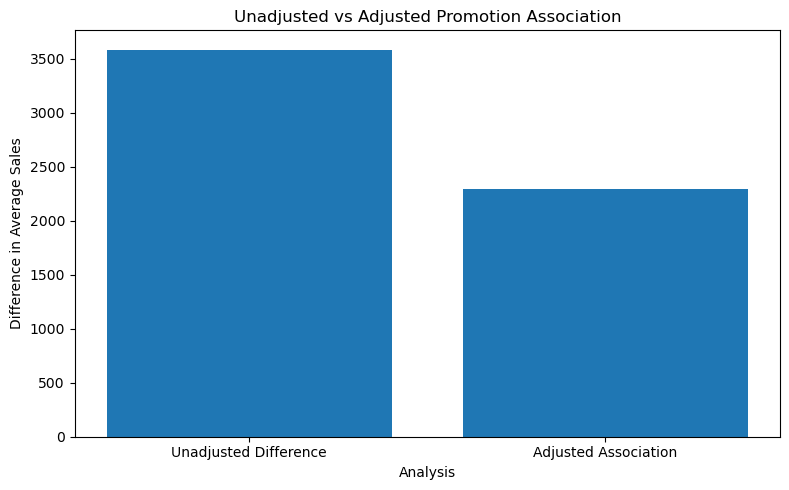

In [25]:
plt.figure(figsize=(8, 5))

plt.bar(
    promotion_comparison["Analysis"],
    promotion_comparison["Sales Difference"]
)

plt.title("Unadjusted vs Adjusted Promotion Association")
plt.xlabel("Analysis")
plt.ylabel("Difference in Average Sales")

plt.tight_layout()
plt.show()

Part of the raw promotion versus non-promotion sales gap is explained by observable store and calendar differences. However, a substantial positive association of approximately 2,294 sales remains after accounting for those factors.

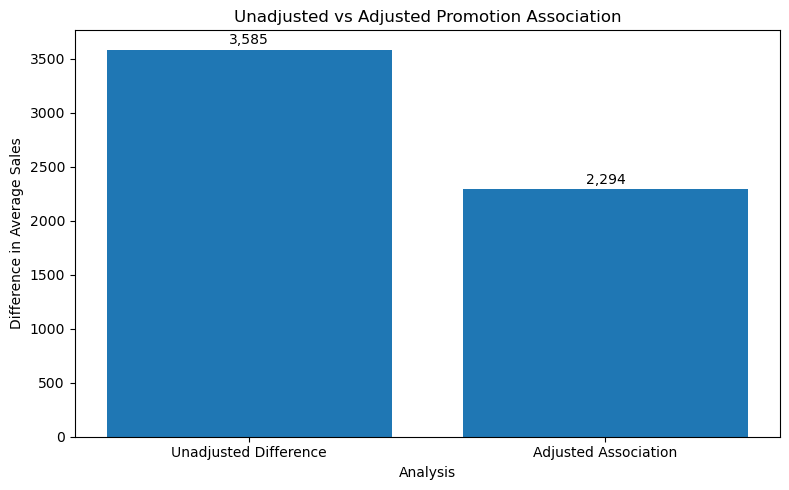

In [26]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    promotion_comparison["Analysis"],
    promotion_comparison["Sales Difference"]
)

plt.title("Unadjusted vs Adjusted Promotion Association")
plt.xlabel("Analysis")
plt.ylabel("Difference in Average Sales")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 50,
        f"{height:,.0f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

## 7. Limitations and Confounding

Although the adjusted regression shows a strong positive association between promotions and sales, the analysis does not establish a causal promotion effect.

The model controls for store-level differences, day of week, school holidays, and state holidays. However, other factors may still influence both promotion timing and sales.

Potential unobserved factors include:

- Seasonal demand patterns
- Store-specific promotion strategies
- Local events
- Competitor activity
- Changes in product availability
- Other business decisions that are not included in the dataset

Promotions may also be scheduled during periods when higher sales are already expected. This makes it difficult to separate the relationship between promotions and sales from the factors influencing when promotions occur.

Therefore, the regression coefficient should be interpreted as an adjusted association rather than evidence that promotions directly caused the estimated increase in sales.

## 8. Summary

### Promotion Overview

Promotions were active in 388,080 observations, representing 38.15% of the dataset.

### Unadjusted Comparison

Average sales were higher during promotional periods:

| Promotion Status | Average Sales |
|---|---:|
| No Promotion | 4,406.05 |
| Promotion | 7,991.15 |

The unadjusted difference was 3,585.10, with average sales during promotional observations being 81.37% higher.

### Store-Level Comparison

Among the 1,115 stores with both promotional and non-promotional observations, 1,114 stores (99.91%) had higher average sales during promotional periods.

This indicates that the positive association between promotions and sales was widespread across the store network.

### Adjusted Analysis

An OLS regression was used to examine the association between promotions and sales while controlling for:

- Store-level differences
- Day of week
- School holidays
- State holidays

After these adjustments, promotion-active observations were associated with approximately 2,293.66 additional sales on average.

The estimated 95% confidence interval was:

- Lower bound: 2,286.54
- Upper bound: 2,300.79

The adjusted association was smaller than the unadjusted difference, suggesting that part of the original sales gap was related to observable store and calendar factors.

### Conclusion

Promotions showed a strong and consistent positive association with sales across the Rossmann store network. The association remained substantial after controlling for observed store and calendar factors.

However, this analysis is observational. The results do not establish that promotions directly caused the estimated increase in sales because unobserved factors may influence both promotion timing and sales.

Therefore, the most appropriate interpretation is that promotions were associated with higher sales, rather than claiming a proven causal promotion effect.